In [3]:
# Bibliotecas
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from google.colab import drive
from google.colab.patches import cv2_imshow
from tf_keras.models import load_model
from tf_keras.preprocessing.image import img_to_array

In [4]:
drive.mount('/content/gdrive') # Acessar o drive

path = "/content/gdrive/MyDrive/Colab Notebooks/Card 23/pratica/Material.zip" # Acessar o Material.zip

zip_object = zipfile.ZipFile(file=path, mode="r") # pegando o arquivo zip
zip_object.extractall("./") # extraindo o arquivo
zip_object.close()

Mounted at /content/gdrive


In [5]:
modelo = load_model("Material/modelo_02_expressoes.h5", compile=False) # carregando o modelo

cascade_faces = "Material/haarcascade_frontalface_default.xml" # cascade faces

face_detection = cv2.CascadeClassifier(cascade_faces) # classificador

expressoes = ["Raiva","Nojo","Medo","Feliz","Triste","Surpreso","Neutro"] # 7 clases de emocoes

In [6]:
arquivo_video = "Material/Videos/video_teste01.mp4" # arquivo de video 2

cap = cv2.VideoCapture(arquivo_video) # captura do video usando o OpenCV

In [7]:
# Variáveis para guardar os resultados
resultados = [] # lista vazia para guardar os resultados

contador_emocoes = {"Raiva": 0, "Nojo": 0, "Medo": 0, "Feliz": 0, "Triste": 0, "Surpreso": 0, "Neutro": 0} # contador dos resultados

Frame: 30


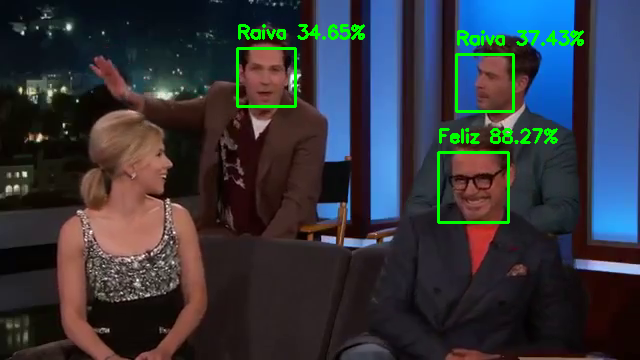

Frame: 60


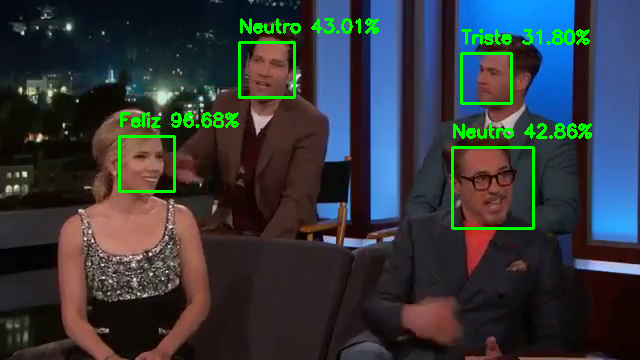

Frame: 90


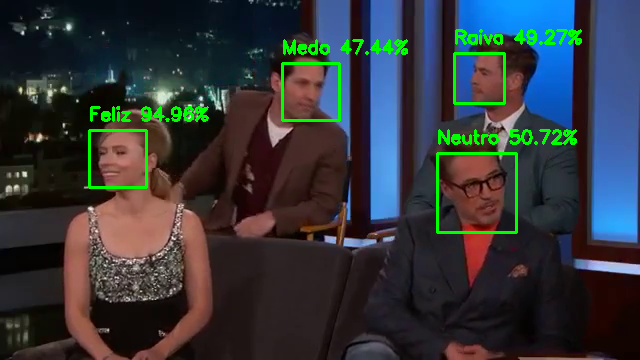

Frame: 120


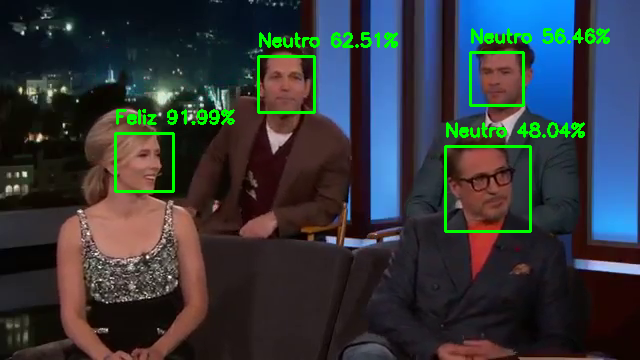

In [8]:
frame_numero = 0 # numero de frames

while True:
    conectado, frame = cap.read()

    if not conectado:
        break

    frame_numero += 1
    rosto_detectado = False

    cinza = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # converte o frame para escala de cinza

    faces = face_detection.detectMultiScale(
        cinza,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(30, 30)
    )

    for (x, y, w, h) in faces: # detecta os rostos

        rosto_detectado = True

        roi = cinza[y:y+h, x:x+w] # região do rosto

        roi = cv2.resize(roi, (48, 48)) # redimensiona para o formato utilizado pelo modelo
        roi = roi.astype("float") / 255.0 # normalização
        roi = img_to_array(roi) # conversão para array
        roi = np.expand_dims(roi, axis=0) # adiciona dimensão para entrada do modelo

        predicao = modelo.predict(roi, verbose=0)[0] # faz a previsão

        indice = np.argmax(predicao) # posição da maior probabilidade
        emocao = expressoes[indice] # emoção correspondente
        confianca = predicao[indice] * 100 # confiança da previsão

        contador_emocoes[emocao] += 1 # adiciona ao contador

        resultados.append({"Frame": frame_numero, "Emocao": emocao, "Confianca": confianca})

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        texto = "{} {:.2f}%".format(emocao, confianca)

        cv2.putText(frame, texto, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    if frame_numero % 30 == 0 and rosto_detectado:
        print("Frame:", frame_numero)
        cv2_imshow(frame)

cap.release()

In [9]:
df_resultados = pd.DataFrame(resultados) # criar tabela dos resultados

df_resultados.head()

,Frame,Emocao,Confianca
0,1,Neutro,49.680511
1,2,Neutro,64.388390
2,3,Neutro,55.448837
3,4,Neutro,47.553097
4,5,Neutro,37.266094


In [10]:
for emocao, quantidade in contador_emocoes.items(): # quantidade de cada emocao
    print(emocao, ":", quantidade)

Raiva : 104
Nojo : 3
Medo : 19
Feliz : 89
Triste : 16
Surpreso : 2
Neutro : 135


In [16]:
emocao_predominante = max(contador_emocoes, key=contador_emocoes.get) # pega a emocao que predominante

print("Emoção predominante:", emocao_predominante) # mostra a emocao predominante

print("Quantidade de detecções:", contador_emocoes[emocao_predominante]) # quantidade de detecao

Emoção predominante: Neutro
Quantidade de detecções: 135


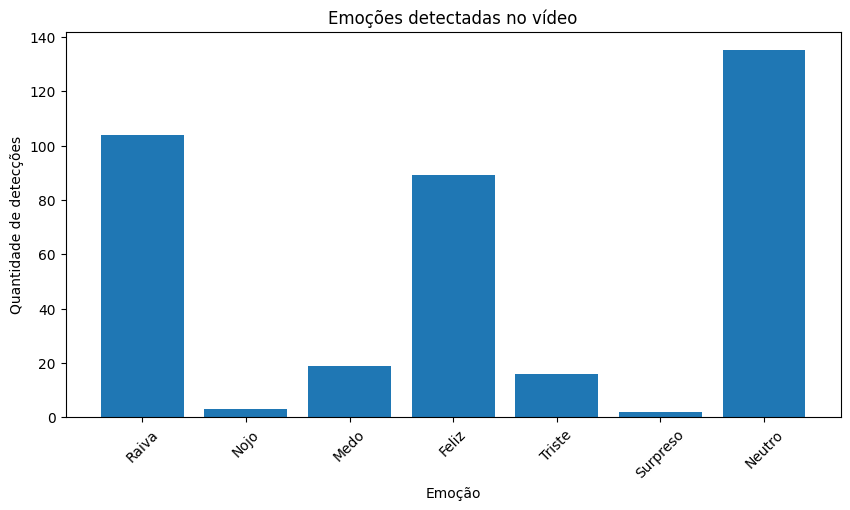

In [17]:
plt.figure(figsize=(10, 5)) # tamanho da figura

plt.bar(contador_emocoes.keys(), contador_emocoes.values())

plt.title("Emoções detectadas no vídeo") # titulo
plt.xlabel("Emoção") # eixo x
plt.ylabel("Quantidade de detecções") # eixo y
plt.xticks(rotation=45) # rotação dos texto do x

plt.show()

In [18]:
df_resultados.to_csv("resultado_emocoes_video.csv", index=False)

print("Arquivo salvo!")

Arquivo salvo!
